# DINOv3 Few-Shot Segmentation on FIB-SEM

Use a frozen DINOv3 encoder to extract patch-token prototypes from a handful of labeled support images, then segment query images via cosine-similarity matching.

| Step | Description |
|------|-------------|
| 1 | Setup & load DINOv3 encoder |
| 2 | Prepare support / query split |
| 3 | Fit prototypes from support masks |
| 4 | Predict & evaluate on query set |
| 5 | Visualize results |

## 1. Setup

In [1]:
%matplotlib inline
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu130


## 2. Load Dataset & DINOv3 Encoder

In [2]:
from lumen.benchmark.dataset import ValDatasetLoader
from lumen.models import DINOv3Encoder

# Load the same FIB-SEM validation dataset used in the benchmark notebook
DATASET_PATH = "/tmp/fibsem_val_dataset_sample/fibsem_val_dataset_sample"
val_ds = ValDatasetLoader(
    path=DATASET_PATH,
    channels=3,          # DINOv3 expects 3-channel input
    image_size=512,      # resize for faster inference
)
print(f"Samples: {len(val_ds)}")
print(f"Names:   {val_ds.names}")
print(f"Classes: {val_ds.num_classes}")

# Load frozen DINOv3 encoder
dinov3_enc = DINOv3Encoder(
    model_dir="/root/.cache/modelscope/hub/models/facebook/dinov3-vits16-pretrain-lvd1689m",
    device=DEVICE,
    local_files_only=True,
)
print(f"DINOv3 embed_dim={dinov3_enc.embed_dim}, patch_size={dinov3_enc.patch_size}")

  2026-05-25T13:56:43.429463Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



Samples: 12
Names:   ['step0_create_marker_fib_60um', 'step0_create_marker_sem_60um', 'step1_protection_layer_fib_60um', 'step1_protection_layer_sem_60um', 'step2_trench_milling_fib_60um', 'step2_trench_milling_sem_60um', 'step3_trench_polish_fib_60um', 'step3_trench_polish_sem_60um', 'step4_ucut_fib_60um', 'step4_ucut_pre_fib_60um', 'step4_ucut_pre_sem_60um', 'step4_ucut_sem_60um']
Classes: 10


/data/codes/lumen/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 5646.50it/s]

DINOv3 embed_dim=384, patch_size=16


## 3. Support / Query Split

In [3]:
# Use first 2 samples as support, rest as query
N_SUPPORT = 2
support_indices = list(range(N_SUPPORT))
query_indices   = list(range(N_SUPPORT, len(val_ds)))

support_images = [val_ds[i].image for i in support_indices]
support_masks  = [val_ds[i].mask  for i in support_indices]
support_names  = [val_ds[i].name  for i in support_indices]

query_images = [val_ds[i].image for i in query_indices]
query_masks  = [val_ds[i].mask  for i in query_indices]
query_names  = [val_ds[i].name  for i in query_indices]

print(f"Support: {support_names}")
print(f"Query:   {query_names}")

Support: ['step0_create_marker_fib_60um', 'step0_create_marker_sem_60um']
Query:   ['step1_protection_layer_fib_60um', 'step1_protection_layer_sem_60um', 'step2_trench_milling_fib_60um', 'step2_trench_milling_sem_60um', 'step3_trench_polish_fib_60um', 'step3_trench_polish_sem_60um', 'step4_ucut_fib_60um', 'step4_ucut_pre_fib_60um', 'step4_ucut_pre_sem_60um', 'step4_ucut_sem_60um']


## 4. Fit Few-Shot Prototypes

In [4]:
from lumen.models import FewShotFeatureMatcher

matcher = FewShotFeatureMatcher(
    encoder=dinov3_enc,
    device=DEVICE,
    min_patch_fraction=0.05,   # lower threshold for small structures
)

matcher.fit(support_images, support_masks)
print(f"Fitted {len(matcher.prototypes)} prototypes for classes: {matcher.label_values.tolist()}")

Fitted 2 prototypes for classes: [0, 2]


## 5. Predict on Query Set

In [5]:
from lumen.benchmark.metrics import compute_metrics, summarize_results

sample_results = []
predictions = []

for idx, (img, mask, name) in enumerate(zip(query_images, query_masks, query_names)):
    pred = matcher.predict(img, output_size=mask.shape)
    pred_labels = pred.labels
    predictions.append(pred_labels)

    sr = compute_metrics(
        pred_labels, mask,
        num_classes=val_ds.num_classes,
        name=name,
        index=idx,
    )
    sample_results.append(sr)

summary = summarize_results(sample_results)
print(f"\nQuery-set mIoU: {summary['mean_iou']:.4f}")
print(f"Query-set Dice: {summary['mean_dice']:.4f}")
print(f"Query-set Pixel Acc: {summary['mean_pixel_acc']:.4f}")


Query-set mIoU: 0.2717
Query-set Dice: 0.3054
Query-set Pixel Acc: 0.9259


## 6. Visualize Support Samples

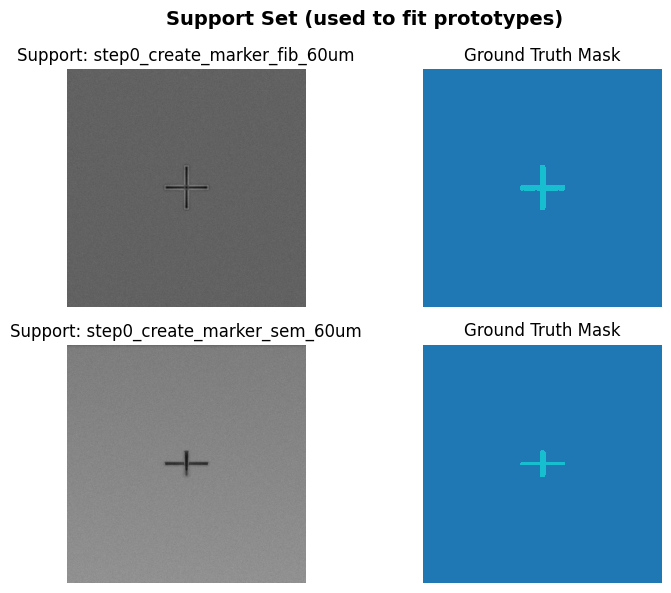

In [6]:
fig, axes = plt.subplots(N_SUPPORT, 2, figsize=(8, 3 * N_SUPPORT))
if N_SUPPORT == 1:
    axes = axes.reshape(1, -1)
for i in range(N_SUPPORT):
    img = support_images[i].permute(1, 2, 0).numpy()
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Support: {support_names[i]}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(support_masks[i].numpy(), cmap="tab10", interpolation="nearest")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")
fig.suptitle("Support Set (used to fit prototypes)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Visualize Query Predictions

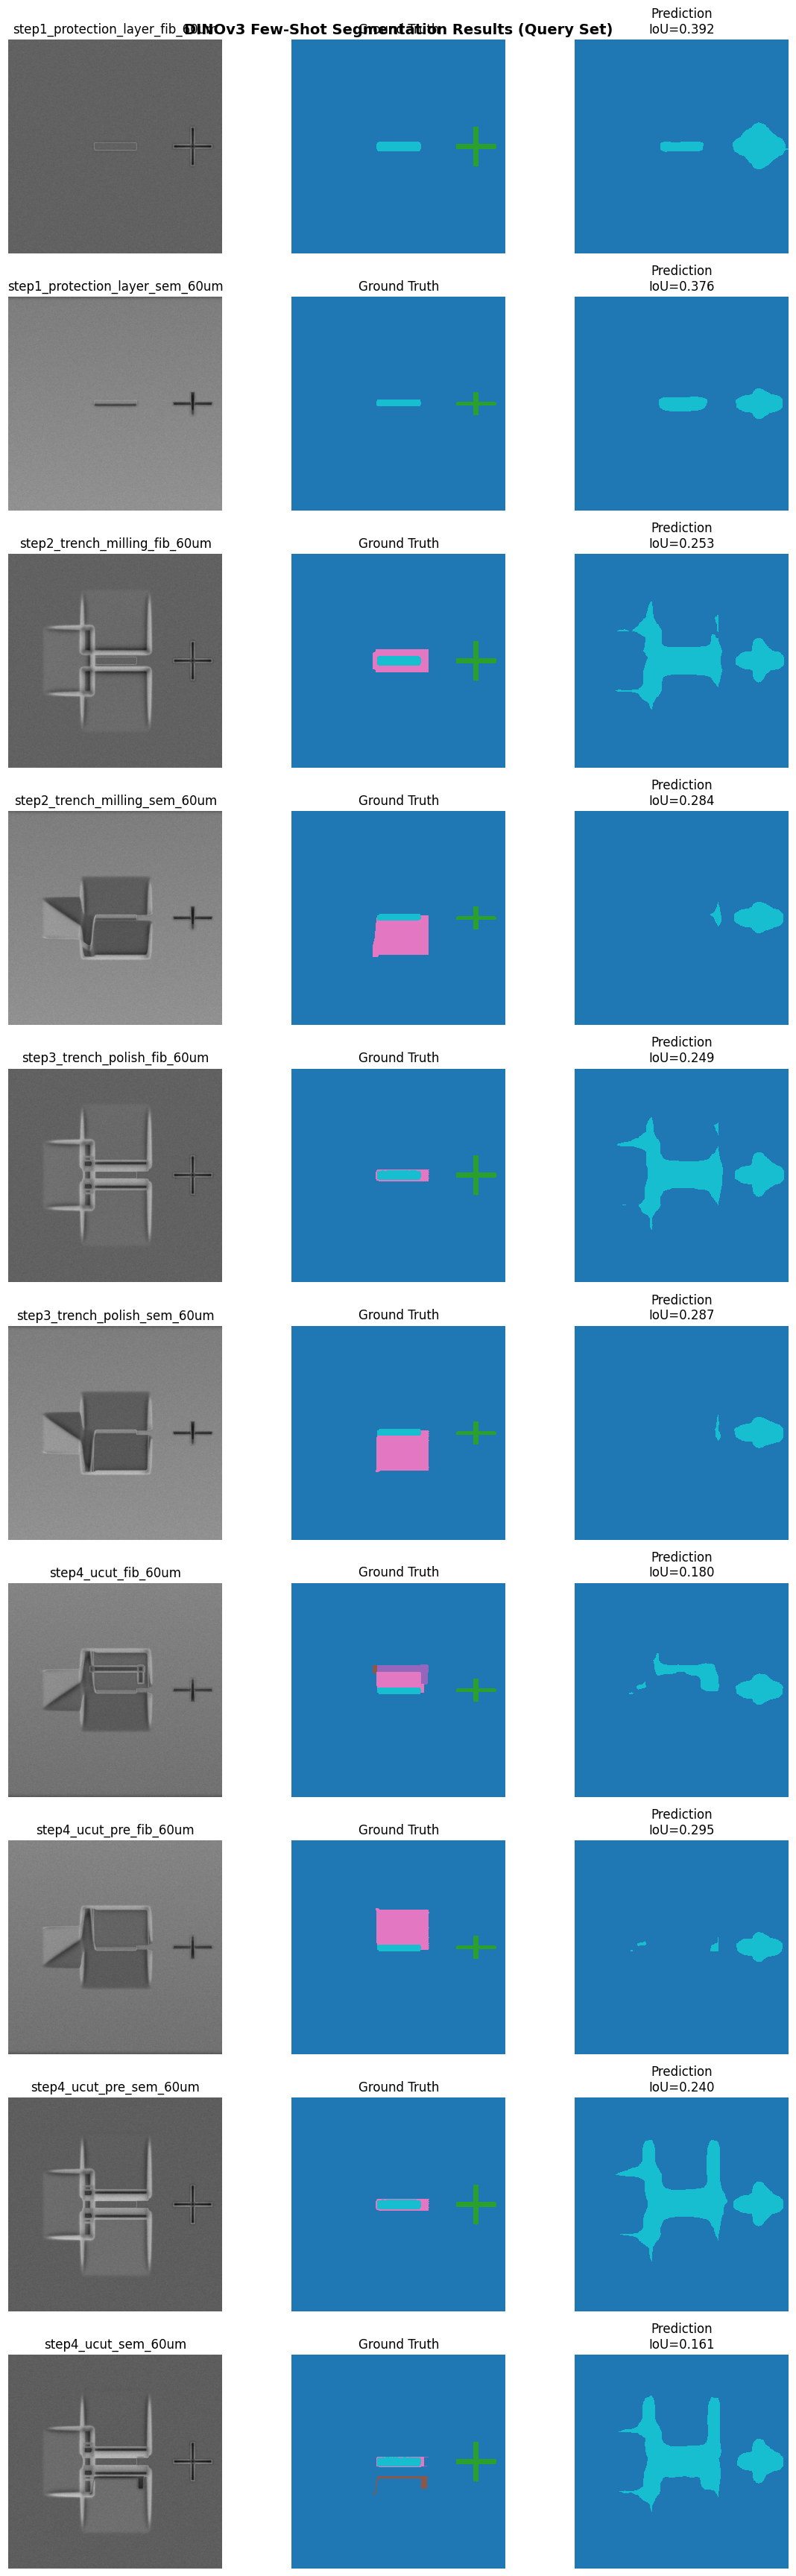

In [7]:
n_query = len(query_images)
fig, axes = plt.subplots(n_query, 3, figsize=(12, 3.5 * n_query))
if n_query == 1:
    axes = axes.reshape(1, -1)

for i in range(n_query):
    img = query_images[i].permute(1, 2, 0).numpy()
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{query_names[i]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(query_masks[i].numpy(), cmap="tab10", interpolation="nearest")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(predictions[i].numpy(), cmap="tab10", interpolation="nearest")
    axes[i, 2].set_title(f"Prediction\nIoU={sample_results[i].iou:.3f}")
    axes[i, 2].axis("off")

fig.suptitle("DINOv3 Few-Shot Segmentation Results (Query Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Per-Sample Score Breakdown

In [8]:
import pandas as pd

df = pd.DataFrame(summary["per_sample"])
print(df.to_string(index=False))
print(f"\nMean — mIoU: {summary['mean_iou']:.4f}, Dice: {summary['mean_dice']:.4f}, PixAcc: {summary['mean_pixel_acc']:.4f}")

                           name      iou     dice  pixel_acc
step1_protection_layer_fib_60um 0.392016 0.441040   0.966042
step1_protection_layer_sem_60um 0.376199 0.416926   0.971413
  step2_trench_milling_fib_60um 0.252882 0.278699   0.904835
  step2_trench_milling_sem_60um 0.283761 0.325774   0.931446
   step3_trench_polish_fib_60um 0.249333 0.276603   0.904064
   step3_trench_polish_sem_60um 0.287099 0.329823   0.933941
            step4_ucut_fib_60um 0.179712 0.198859   0.944557
        step4_ucut_pre_fib_60um 0.295083 0.339789   0.936844
        step4_ucut_pre_sem_60um 0.240243 0.267445   0.882240
            step4_ucut_sem_60um 0.160678 0.178872   0.883591

Mean — mIoU: 0.2717, Dice: 0.3054, PixAcc: 0.9259
